# Classification - Blood Group Detection

Notebook nay train baseline classifiers tu file `processed/color_segmentation/color_segmentation_features.csv`.

Muc tieu:
- Doc feature CSV da tao o notebook 02.
- Train/evaluate mot so model truyen thong.
- Chon model tot nhat theo `f1_macro`.
- Luu model package vao folder `models/` de dung lai sau.

Luu y: split goc cua dataset bi lech lop manh, nen mac dinh notebook dung stratified split tren toan bo feature CSV.

In [ ]:
from pathlib import Path
from datetime import datetime
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

ROOT = Path.cwd()
FEATURE_PATH = ROOT / "processed" / "color_segmentation" / "color_segmentation_features.csv"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "blood_group"  # Options: blood_group, abo, rh
USE_ORIGINAL_SPLIT = False
TEST_SIZE = 0.20

ROOT, FEATURE_PATH, MODEL_DIR

(WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco'),
 WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/processed/color_segmentation/color_segmentation_features.csv'),
 WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/models'))

## 1. Load Feature CSV

In [ ]:
if not FEATURE_PATH.exists():
    raise FileNotFoundError(f"Feature CSV not found: {FEATURE_PATH}")

df = pd.read_csv(FEATURE_PATH)
print("shape:", df.shape)
print("columns:", len(df.columns))
print("nan total:", int(df.isna().sum().sum()))
df.head()

shape: (2072, 387)
columns: 387
nan total: 0


,split,file_name,blood_group,abo,rh,resized_width,resized_height,anti_a_blue_mask_present,anti_a_blue_area_ratio,anti_a_blue_component_count,...,reaction_candidate_lbp_hist_11,reaction_candidate_lbp_hist_12,reaction_candidate_lbp_hist_13,reaction_candidate_lbp_hist_14,reaction_candidate_lbp_hist_15,reaction_candidate_lbp_entropy,reaction_candidate_glcm_contrast,reaction_candidate_glcm_homogeneity,reaction_candidate_glcm_energy,reaction_candidate_glcm_entropy
0,train,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B-,B,-,1200,393,0,0.000000,0,...,0.037551,0.062214,0.034466,0.080536,0.326051,3.369219,0.104028,0.952790,0.370673,3.443889
1,train,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB-,AB,-,991,302,1,0.108122,1,...,0.018770,0.092556,0.014052,0.098168,0.302539,3.195161,0.251669,0.910492,0.318408,3.852862
2,train,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+,A,+,1200,365,1,0.058824,3,...,0.032756,0.068258,0.027687,0.085560,0.282160,3.414465,0.149818,0.932946,0.334683,3.731031
3,train,A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg,A+,A,+,1199,363,1,0.011015,2,...,0.031719,0.071115,0.034433,0.095530,0.243070,3.525242,0.303345,0.894136,0.309172,4.018971
4,train,B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg,B-,B,-,1019,341,0,0.000000,0,...,0.016504,0.073804,0.013279,0.100860,0.367621,3.047156,0.206681,0.912349,0.347532,3.640129


In [ ]:
print("Target distribution:")
print(df[TARGET].value_counts())

print("\nSplit x target:")
print(pd.crosstab(df[TARGET], df["split"]))

Target distribution:
blood_group
A+     300
O+     299
B+     299
B-     298
A-     296
AB+    292
AB-    285
O-       3
Name: count, dtype: int64

Split x target:
split        test  train  valid
blood_group                    
A+              1    299      0
A-            168    128      0
AB+            71    110    111
AB-             0    100    185
B+              0    150    149
B-              0    298      0
O+              0    299      0
O-              0      2      1


## 2. Prepare Features

Chi dung cac cot numeric lam feature. Metadata va label columns duoc loai ra. `SimpleImputer(fill_value=0)` van duoc giu trong pipeline nhu lop bao ve neu sau nay CSV co NaN.

In [ ]:
metadata_cols = ["split", "file_name", "blood_group", "abo", "rh"]
numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c not in metadata_cols]

X = df[feature_cols]
y = df[TARGET].astype(str)

print("target:", TARGET)
print("feature count:", len(feature_cols))
print("sample features:", feature_cols[:12])
print("classes:", sorted(y.unique()))

target: blood_group
feature count: 382
sample features: ['resized_width', 'resized_height', 'anti_a_blue_mask_present', 'anti_a_blue_area_ratio', 'anti_a_blue_component_count', 'anti_a_blue_largest_component_area', 'anti_a_blue_largest_component_ratio', 'anti_a_blue_contour_count', 'anti_a_blue_max_contour_area_ratio', 'anti_a_blue_max_contour_perimeter_ratio', 'anti_a_blue_max_contour_circularity', 'anti_a_blue_r_mean']
classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


## 3. Train/Test Split

`USE_ORIGINAL_SPLIT = False` la mac dinh vi split goc khong dai dien du 8 nhom mau. Neu muon so sanh voi split goc, doi thanh `True` o cell config dau tien.

In [ ]:
if USE_ORIGINAL_SPLIT:
    train_mask = df["split"] == "train"
    test_mask = df["split"].isin(["valid", "test"])
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
else:
    min_count = y.value_counts().min()
    if min_count < 2:
        raise ValueError("Stratified split needs at least 2 samples per class.")
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("\nTrain distribution:")
print(y_train.value_counts())
print("\nTest distribution:")
print(y_test.value_counts())

X_train: (1657, 382) X_test: (415, 382)

Train distribution:
blood_group
A+     240
B+     239
O+     239
B-     238
A-     237
AB+    234
AB-    228
O-       2
Name: count, dtype: int64

Test distribution:
blood_group
O+     60
A+     60
B-     60
B+     60
A-     59
AB+    58
AB-    57
O-      1
Name: count, dtype: int64


## 4. Define Candidate Models

In [ ]:
def scaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])


def tree_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("model", model),
    ])


models = {
    "logistic_regression": scaled_pipeline(
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "linear_svm": scaled_pipeline(
        LinearSVC(class_weight="balanced", max_iter=10000, random_state=RANDOM_STATE)
    ),
    "rbf_svm": scaled_pipeline(
        SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "knn": scaled_pipeline(
        KNeighborsClassifier(n_neighbors=5)
    ),
    "random_forest": tree_pipeline(
        RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    ),
    "extra_trees": tree_pipeline(
        ExtraTreesClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    ),
}

list(models.keys())

['logistic_regression',
 'linear_svm',
 'rbf_svm',
 'knn',
 'random_forest',
 'extra_trees']

## 5. Cross-Validation and Test Evaluation

In [ ]:
min_train_count = y_train.value_counts().min()
n_splits = max(2, min(3, int(min_train_count)))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

rows = []
fitted_models = {}

for name, pipe in models.items():
    print(f"Training {name}...")
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rows.append({
        "model": name,
        "cv_f1_macro_mean": cv_scores.mean(),
        "cv_f1_macro_std": cv_scores.std(),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1_macro": f1_score(y_test, pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, pred, average="weighted"),
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
results_df

Training logistic_regression...
Training linear_svm...
Training rbf_svm...
Training knn...
Training random_forest...
Training extra_trees...


,model,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,test_f1_weighted
0,rbf_svm,0.780320,0.000034,0.939759,0.823653,0.938636
1,extra_trees,0.774244,0.011281,0.920482,0.806234,0.919002
2,random_forest,0.768354,0.000721,0.906024,0.793394,0.904512
3,logistic_regression,0.767558,0.002563,0.896386,0.786019,0.895741
4,linear_svm,0.737287,0.002900,0.877108,0.769744,0.877380
5,knn,0.668659,0.001659,0.816867,0.715245,0.815462


In [ ]:
best_name = results_df.loc[0, "model"]
best_model = fitted_models[best_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_name)
print(classification_report(y_test, best_pred, digits=4))

Best model: rbf_svm
              precision    recall  f1-score   support

          A+     0.9048    0.9500    0.9268        60
          A-     0.9000    0.9153    0.9076        59
         AB+     0.9828    0.9828    0.9828        58
         AB-     1.0000    0.9649    0.9821        57
          B+     0.9808    0.8500    0.9107        60
          B-     0.9516    0.9833    0.9672        60
          O+     0.8769    0.9500    0.9120        60
          O-     0.0000    0.0000    0.0000         1

    accuracy                         0.9398       415
   macro avg     0.8246    0.8245    0.8237       415
weighted avg     0.9396    0.9398    0.9386       415



e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


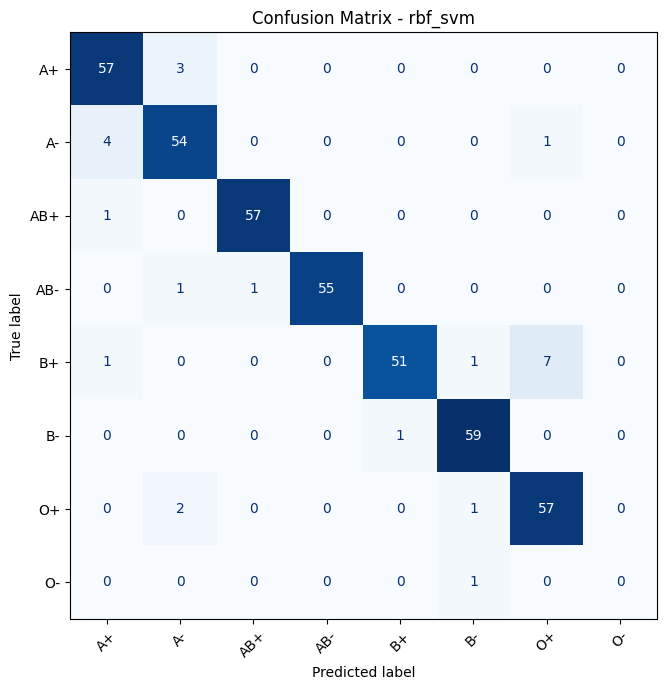

In [ ]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pickle
from datetime import datetime
from sklearn.metrics import classification_report

# 1. Tạo timestamp chuẩn để tên file đồng bộ
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 2. Định nghĩa đường dẫn cho tất cả các file cần lưu
joblib_path = MODEL_DIR / f"color_segmentation_{TARGET}_{best_name}_{timestamp}.joblib"
pkl_path = MODEL_DIR / f"color_segmentation_{TARGET}_{best_name}_{timestamp}.pkl"
metrics_path = MODEL_DIR / f"color_segmentation_{TARGET}_metrics_{timestamp}.csv"
report_path = MODEL_DIR / f"color_segmentation_{TARGET}_classification_report_{timestamp}.txt"

# 3. Đóng gói mô hình và các metadata quan trọng
model_package = {
    "model": best_model,
    "model_name": best_name,
    "target": TARGET,
    "feature_columns": feature_cols,
    "classes": labels,
    "feature_path": str(FEATURE_PATH),
    "use_original_split": USE_ORIGINAL_SPLIT,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "saved_at": timestamp,
    "metrics": results_df.to_dict(orient="records"),
}

# 4. Lưu file .joblib
joblib.dump(model_package, joblib_path, compress=3)
print(f"Đã lưu Joblib tại: {joblib_path}")

# 5. Lưu file .pkl
with open(pkl_path, "wb") as f:
    pickle.dump(model_package, f)
print(f"Đã lưu Pickle tại: {pkl_path}")

# 6. Lưu file CSV chứa metrics và file TXT chứa report
results_df.to_csv(metrics_path, index=False)
with report_path.open("w", encoding="utf-8") as f:
    f.write(f"Best model: {best_name}\n")
    f.write(f"Target: {TARGET}\n")
    f.write(f"Saved at: {timestamp}\n\n")
    f.write(classification_report(y_test, best_pred, digits=4))

# Hiển thị đường dẫn các file đã lưu để kiểm tra
joblib_path, pkl_path, metrics_path, report_path

Đã lưu Joblib tại: e:\LUT\PatternRecognition\Final\Blood Group Detection.coco\models\color_segmentation_blood_group_rbf_svm_20260604_161917.joblib
Đã lưu Pickle tại: e:\LUT\PatternRecognition\Final\Blood Group Detection.coco\models\color_segmentation_blood_group_rbf_svm_20260604_161917.pkl


e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/models/color_segmentation_blood_group_rbf_svm_20260604_161917.joblib'),
 WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/models/color_segmentation_blood_group_rbf_svm_20260604_161917.pkl'),
 WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/models/color_segmentation_blood_group_metrics_20260604_161917.csv'),
 WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco/models/color_segmentation_blood_group_classification_report_20260604_161917.txt'))

In [ ]:
loaded_package = joblib.load(joblib_path)
loaded_model = loaded_package["model"]
loaded_features = loaded_package["feature_columns"]

sample = df.sample(10, random_state=RANDOM_STATE)
sample_pred = loaded_model.predict(sample[loaded_features])

pd.DataFrame({
    "file_name": sample["file_name"].values,
    "true_label": sample[TARGET].values,
    "pred_label": sample_pred,
})

,file_name,true_label,pred_label
0,B+ (58)_jpg.rf.I3orMQDrL1FRmrVNSw1s.jpg,B+,B+
1,B- (96)_jpg.rf.1tvOcBmVMchFdTSOpvtX.jpg,B-,B-
2,B- (123)_jpg.rf.gbt9xfXECQH0Vm0eaxQm.jpg,B-,B-
3,B+ (114)_jpg.rf.PdepoPOh8YbZJ8ZWorlJ.jpg,B+,B+
4,B- (50)_jpg.rf.cMKqC9dGna7ovPdlnTGK.jpg,B-,B-
5,A+ (100)_jpg.rf.f4M0SfLjI5o8Rq8UkAvX.jpg,A+,A+
6,B+ (54)_jpg.rf.yCzUowNbL8ECNb5DYlCv.jpg,B+,B+
7,B- (116)_jpg.rf.UalXNlK7fRUxt1tGNp2J.jpg,B-,B-
8,B- (72)_jpg.rf.Juhy0TtV5e4SVstElFUK.jpg,B-,B-
9,A- (78)_jpg.rf.3Bd3tbW8fmgmY3sOWcor.jpg,A-,A-


## Notes for Report

- Neu target la `blood_group`, lop `O-` chi co 3 anh nen metric cua lop nay rat khong on dinh.
- Nen bao cao them `macro F1`, khong chi accuracy, vi dataset lech lop.
- Co the train rieng hai bai toan `abo` va `rh` de so sanh voi bai toan 8 lop `blood_group`.